# Experiment 13: ArcFace Hyperparameter Sweep on DINOv2 Embeddings

## Research Question

Is the default ArcFace configuration (margin=0.5, scale=64, embdim=256) optimal for
jaguar re-ID on frozen DINOv2-ViT-L/14 embeddings, or does a 3-stage grid sweep of
margin, scale, embedding dimension, hidden dimension, and dropout push mAP beyond the
Exp 4 baseline of 0.8447?

## Overview

1. Load cached DINOv2-ViT-L-14 embeddings — no image loading at any stage
2. Stage 1: Sweep margin (0.2, 0.3, 0.4, 0.5, 0.6, 0.7) × scale (48, 64, 80, 128)
3. Stage 2: Sweep embedding dim (128, 256, 512, 1024) using best margin+scale from Stage 1
4. Stage 3: Sweep hidden dim (512, 1024) and dropout (0.1, 0.3, 0.5) using best settings from Stages 1 and 2
5. Pick best overall configuration and generate submission

## Controlled Variables

Backbone: DINOv2-ViT-L-14, frozen throughout (Exp 4 cache reused).  
Optimizer: AdamW (lr=1e-4, weight_decay=1e-4).  
Scheduler: ReduceLROnPlateau (factor=0.5, patience=10).  
Epochs: 50, batch size: 32, seed: 42.  
Baseline: mAP 0.8447 (margin=0.5, scale=64, dim=256, hidden=512, dropout=0.3)  

## 1. Setup

In [1]:
import os, math, time, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

RANDOM_SEED = 42

def set_seed(seed):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}  |  PyTorch: {torch.__version__}")


Device: cuda  |  PyTorch: 2.9.0+cu126


In [2]:
RANDOM_SEED = 42

# Baseline from Exp 
EXP4_BASELINE_MAP = 0.8447

# Stage 1: Margin × Scale sweep
STAGE1_MARGINS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
STAGE1_SCALES  = [48.0, 64.0, 80.0, 128.0]

# Stage 2: Embedding dimension (uses best margin+scale from Stage 1)
STAGE2_EMB_DIMS = [128, 256, 512, 1024]

# Stage 3: Hidden dim + Dropout (uses best from Stages 1+2)
STAGE3_CONFIGS = [
    {"hidden_dim": 512,  "dropout": 0.1},
    {"hidden_dim": 512,  "dropout": 0.3},   # Exp 4 default
    {"hidden_dim": 512,  "dropout": 0.5},
    {"hidden_dim": 1024, "dropout": 0.1},
    {"hidden_dim": 1024, "dropout": 0.3},
    {"hidden_dim": 1024, "dropout": 0.5},
]

config = {
    "data_dir":   Path("/kaggle/input/competitions/jaguar-re-id"),
    "cache_dir":  Path("/kaggle/working/embeddings"),

    # Backbone (frozen — embeddings reused from Exp 4 / Exp 9 cache)
    "dinov2_model":      "vit_large_patch14_dinov2.lvd142m",
    "dinov2_input_size": 518,

    # Fixed training hyperparameters (identical to Exp 4)
    "batch_size":    32,
    "learning_rate": 1e-4,
    "weight_decay":  1e-4,
    "num_epochs":    50,
    "patience":      10,
    "val_split":     0.2,
    "seed":          RANDOM_SEED,
}

config["cache_dir"].mkdir(parents=True, exist_ok=True)

total_s1 = len(STAGE1_MARGINS) * len(STAGE1_SCALES)
total_s2 = len(STAGE2_EMB_DIMS)
total_s3 = len(STAGE3_CONFIGS)
print(f"Exp 4 baseline: mAP={EXP4_BASELINE_MAP} (margin=0.5, scale=64, dim=256, hidden=512, dropout=0.3)")
print(f"Stage 1 configs: {total_s1}  (margin × scale)")
print(f"Stage 2 configs: {total_s2}  (embedding dim)")
print(f"Stage 3 configs: {total_s3}  (hidden dim + dropout)")
print(f"All stages use cached DINOv2 embeddings — no image loading")


Exp 4 baseline: mAP=0.8447 (margin=0.5, scale=64, dim=256, hidden=512, dropout=0.3)
Stage 1 configs: 24  (margin × scale)
Stage 2 configs: 4  (embedding dim)
Stage 3 configs: 6  (hidden dim + dropout)
All stages use cached DINOv2 embeddings — no image loading


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        "experiment":        "arcface-sweep-dinov2",
        "backbone":          "DINOv2-ViT-L-14 (frozen, Exp4 cache)",
        "loss":              "CrossEntropy + ArcFace",
        "stage1_margins":    STAGE1_MARGINS,
        "stage1_scales":     STAGE1_SCALES,
        "stage2_emb_dims":   STAGE2_EMB_DIMS,
        "stage3_configs":    STAGE3_CONFIGS,
        "exp4_baseline":     EXP4_BASELINE_MAP,
        "lr":                config["learning_rate"],
        "batch_size":        config["batch_size"],
        "num_epochs":        config["num_epochs"],
        "seed":              RANDOM_SEED,
    },
    name="arcface-sweep-dinov2",
)
print("W&B run: arcface-sweep-dinov2")


W&B run: arcface-sweep-dinov2


## 2. Load Data and Cached DINOv2 Embeddings

In [5]:
train_df = pd.read_csv(config["data_dir"] / "train.csv")
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df, test_size=config["val_split"],
    random_state=config["seed"], stratify=train_df['ground_truth'])

train_labels_enc = train_data['label_encoded'].values
val_labels_enc   = label_encoder.transform(val_data['ground_truth'].values)
val_labels_str   = val_data['ground_truth'].values

print(f"Train: {len(train_data)}  |  Val: {len(val_data)}  |  Classes: {num_classes}")


Train: 1516  |  Val: 379  |  Classes: 31


In [6]:
d_tr_cache = config["cache_dir"] / "dinov2_train_embeddings.npz"
d_va_cache = config["cache_dir"] / "dinov2_val_embeddings.npz"

if d_tr_cache.exists() and d_va_cache.exists():
    train_bb = np.load(d_tr_cache)["embeddings"]
    val_bb   = np.load(d_va_cache)["embeddings"]
    print(f"Loaded cached DINOv2 embeddings ✓")
    print(f"  Train: {train_bb.shape}  Val: {val_bb.shape}")
    dinov2_dim = train_bb.shape[1]
else:
    # Extract from scratch if cache missing
    print("Cache not found — extracting DINOv2 embeddings...")
    train_paths = [config["data_dir"] / "train/train" / fn
                   for fn in train_data["filename"].astype(str)]
    val_paths   = [config["data_dir"] / "train/train" / fn
                   for fn in val_data["filename"].astype(str)]

    backbone = timm.create_model(config["dinov2_model"], pretrained=True,
                                  num_classes=0, img_size=config["dinov2_input_size"])
    backbone.eval()
    for p in backbone.parameters(): p.requires_grad = False
    backbone.to(device)
    with torch.no_grad():
        dinov2_dim = backbone(torch.randn(1,3,518,518).to(device)).shape[1]

    preprocess = transforms.Compose([
        transforms.Resize((518, 518)), transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])

    @torch.no_grad()
    def extract(paths, desc):
        out = []
        for i in tqdm(range(0, len(paths), 32), desc=desc):
            tensors = []
            for p in paths[i:i+32]:
                try:    tensors.append(preprocess(Image.open(p).convert("RGB")))
                except: tensors.append(torch.zeros(3,518,518))
            out.append(backbone(torch.stack(tensors).to(device)).cpu().numpy())
        return np.vstack(out)

    train_bb = extract(train_paths, "DINOv2 train")
    val_bb   = extract(val_paths,   "DINOv2 val")
    np.savez_compressed(d_tr_cache, embeddings=train_bb)
    np.savez_compressed(d_va_cache, embeddings=val_bb)
    del backbone; torch.cuda.empty_cache()
    print(f"Extracted and cached: train={train_bb.shape}  val={val_bb.shape}")

print(f"Backbone output dim: {dinov2_dim}")


Cache not found — extracting DINOv2 embeddings...


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

DINOv2 train:   0%|          | 0/48 [00:00<?, ?it/s]

DINOv2 val:   0%|          | 0/12 [00:00<?, ?it/s]

Extracted and cached: train=(1516, 1024)  val=(379, 1024)
Backbone output dim: 1024


## 3. Architecture and Training Utilities

In [7]:
class EmbeddingProjection(nn.Module):
    """Projection head — width/depth/dropout are configurable per stage."""    
    def __init__(self, input_dim, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x):         return self.net(x)
    def get_embeddings(self, x):  return F.normalize(self.net(x), p=2, dim=1)


class ArcFaceHead(nn.Module):
    """Additive Angular Margin — margin and scale are configurable."""   
    def __init__(self, emb_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.scale = scale
        self.cos_m  = math.cos(margin); self.sin_m = math.sin(margin)
        self.th     = math.cos(math.pi - margin)
        self.mm     = math.sin(math.pi - margin) * margin
        self.W      = nn.Parameter(torch.FloatTensor(num_classes, emb_dim))
        nn.init.xavier_uniform_(self.W)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.W, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1, 1)
        sin   = (1 - cos**2).clamp(min=1e-12).sqrt()
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1,1).long(), 1)
        return (oh * phi + (1-oh) * cos) * self.scale


class EmbeddingDataset(torch.utils.data.Dataset):
    def __init__(self, embs, labels):
        self.embs = torch.FloatTensor(embs)
        self.labels = torch.LongTensor(labels)
    def __len__(self):          return len(self.labels)
    def __getitem__(self, idx): return self.embs[idx], self.labels[idx]


def map_from_embeddings(emb, labels):
    emb  = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sim  = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql  = labels[q]; is_m = (labels==ql).astype(int); is_m[q] = 0
        n_pos = is_m.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_m[order]
        cum   = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec*sm)/n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


print("Architecture defined ✓  (EmbeddingProjection, ArcFaceHead, map_from_embeddings)")


Architecture defined ✓  (EmbeddingProjection, ArcFaceHead, map_from_embeddings)


In [8]:
def run_config(tag, margin, scale, emb_dim, hidden_dim, dropout,
               wandb_prefix, log_curve=False):
    """
    Train one ArcFace configuration on cached DINOv2 embeddings.
    Returns best val mAP. All hyperparameters are explicit arguments.
    """
    set_seed(config["seed"])

    proj  = EmbeddingProjection(dinov2_dim, hidden_dim, emb_dim, dropout).to(device)
    head  = ArcFaceHead(emb_dim, num_classes, margin, scale).to(device)
    crit  = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        EmbeddingDataset(train_bb, train_labels_enc),
        batch_size=config["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(
        EmbeddingDataset(val_bb, val_labels_enc),
        batch_size=config["batch_size"], shuffle=False)

    opt   = torch.optim.AdamW(
        list(proj.parameters()) + list(head.parameters()),
        lr=config["learning_rate"], weight_decay=config["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=5)

    best_proj  = {k: v.clone() for k, v in proj.state_dict().items()}
    best_head  = {k: v.clone() for k, v in head.state_dict().items()}
    best_vloss = float('inf')
    best_map   = 0.0
    best_ep    = 0
    patience_c = 0
    val_maps   = []

    for epoch in range(config["num_epochs"]):
        # Train
        proj.train(); head.train(); tr_loss = 0.0
        for emb, labels in train_loader:
            emb, labels = emb.to(device), labels.to(device)
            loss = crit(head(proj(emb), labels), labels)
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item()
        tr_loss /= len(train_loader)

        # Validate
        proj.eval(); head.eval(); va_loss = 0.0
        with torch.no_grad():
            for emb, labels in val_loader:
                emb, labels = emb.to(device), labels.to(device)
                va_loss += crit(head(proj(emb), labels), labels).item()
        va_loss /= len(val_loader)

        # mAP
        with torch.no_grad():
            ve = proj.get_embeddings(
                torch.FloatTensor(val_bb).to(device)).cpu().numpy()
        va_map = map_from_embeddings(ve, val_labels_str)
        val_maps.append(va_map)
        sched.step(va_loss)

        if log_curve:
            wandb.log({f"{wandb_prefix}/epoch": epoch+1,
                       f"{wandb_prefix}/train_loss": tr_loss,
                       f"{wandb_prefix}/val_loss":   va_loss,
                       f"{wandb_prefix}/val_map":    va_map})

        loss_ok    = (va_loss == va_loss)
        map_better = va_map > best_map
        if loss_ok and (va_loss < best_vloss): best_vloss = va_loss
        if map_better or (loss_ok and va_loss < best_vloss):
            if map_better:
                best_map = va_map; best_ep = epoch+1
                best_proj = {k: v.clone() for k, v in proj.state_dict().items()}
                best_head = {k: v.clone() for k, v in head.state_dict().items()}
            patience_c = 0
        else:
            patience_c += 1
            if patience_c >= config["patience"]: break

    wandb.log({f"{wandb_prefix}/best_map":   best_map,
               f"{wandb_prefix}/best_epoch": best_ep,
               f"{wandb_prefix}/gain":       best_map - EXP4_BASELINE_MAP})

    # Restore best and return val embeddings
    proj.load_state_dict(best_proj)
    proj.eval()
    with torch.no_grad():
        best_val_emb = proj.get_embeddings(
            torch.FloatTensor(val_bb).to(device)).cpu().numpy()

    return best_map, best_ep, best_val_emb, proj


print("run_config() training function defined ✓")
print("Each call: trains from scratch, in-memory checkpoint, returns best mAP")


run_config() training function defined ✓
Each call: trains from scratch, in-memory checkpoint, returns best mAP


## 4. Stage 1 — Margin × Scale Grid Sweep

Fixing: embedding_dim=256, hidden_dim=512, dropout=0.3  (Exp 4 defaults)
Sweeping: margin ∈ {0.2, 0.3, 0.4, 0.5, 0.6, 0.7} × scale ∈ {48, 64, 80, 128}


In [9]:
stage1_results = []
total_s1 = len(STAGE1_MARGINS) * len(STAGE1_SCALES)
done = 0

print(f"Stage 1: {total_s1} configs  (dim=256, hidden=512, dropout=0.3)")
print(f"Baseline: mAP={EXP4_BASELINE_MAP} (margin=0.5, scale=64)")
print()

for margin in STAGE1_MARGINS:
    for scale in STAGE1_SCALES:
        done += 1
        tag = f"m{str(margin).replace('.','')}_s{int(scale)}"
        t0  = time.perf_counter()
        val_map, best_ep, _, _ = run_config(
            tag=tag, margin=margin, scale=scale,
            emb_dim=256, hidden_dim=512, dropout=0.3,
            wandb_prefix=f"stage1/{tag}")
        elapsed = time.perf_counter() - t0
        gain    = val_map - EXP4_BASELINE_MAP

        stage1_results.append({
            "margin": margin, "scale": scale,
            "val_map": val_map, "gain": gain,
            "best_epoch": best_ep, "time_s": elapsed,
        })
        marker = " ★ BEST" if val_map == max(r["val_map"] for r in stage1_results) else ""
        print(f"  [{done:2d}/{total_s1}] margin={margin:.1f} scale={int(scale):3d} | "
              f"mAP={val_map:.4f} ({gain:+.4f}) | ep={best_ep:3d} | "
              f"{elapsed/60:.1f}min{marker}")

stage1_results.sort(key=lambda r: -r["val_map"])
best_s1 = stage1_results[0]
print(f"\nStage 1 best: margin={best_s1['margin']}, scale={int(best_s1['scale'])} "
      f"→ mAP={best_s1['val_map']:.4f} ({best_s1['gain']:+.4f} vs Exp4)")

wandb.log({"stage1/best_margin":  best_s1["margin"],
           "stage1/best_scale":   best_s1["scale"],
           "stage1/best_map":     best_s1["val_map"],
           "stage1/best_gain":    best_s1["gain"]})


Stage 1: 24 configs  (dim=256, hidden=512, dropout=0.3)
Baseline: mAP=0.8447 (margin=0.5, scale=64)

  [ 1/24] margin=0.2 scale= 48 | mAP=0.7687 (-0.0760) | ep= 49 | 0.2min ★ BEST
  [ 2/24] margin=0.2 scale= 64 | mAP=0.7610 (-0.0837) | ep= 46 | 0.2min
  [ 3/24] margin=0.2 scale= 80 | mAP=0.7574 (-0.0873) | ep= 48 | 0.2min
  [ 4/24] margin=0.2 scale=128 | mAP=0.7498 (-0.0949) | ep= 47 | 0.2min
  [ 5/24] margin=0.3 scale= 48 | mAP=0.8080 (-0.0367) | ep= 48 | 0.2min ★ BEST
  [ 6/24] margin=0.3 scale= 64 | mAP=0.8055 (-0.0392) | ep= 48 | 0.2min
  [ 7/24] margin=0.3 scale= 80 | mAP=0.8038 (-0.0409) | ep= 47 | 0.2min
  [ 8/24] margin=0.3 scale=128 | mAP=0.8011 (-0.0436) | ep= 50 | 0.2min
  [ 9/24] margin=0.4 scale= 48 | mAP=0.8219 (-0.0228) | ep= 50 | 0.2min ★ BEST
  [10/24] margin=0.4 scale= 64 | mAP=0.8208 (-0.0239) | ep= 50 | 0.2min
  [11/24] margin=0.4 scale= 80 | mAP=0.8197 (-0.0250) | ep= 50 | 0.2min
  [12/24] margin=0.4 scale=128 | mAP=0.8192 (-0.0255) | ep= 50 | 0.2min
  [13/24] marg

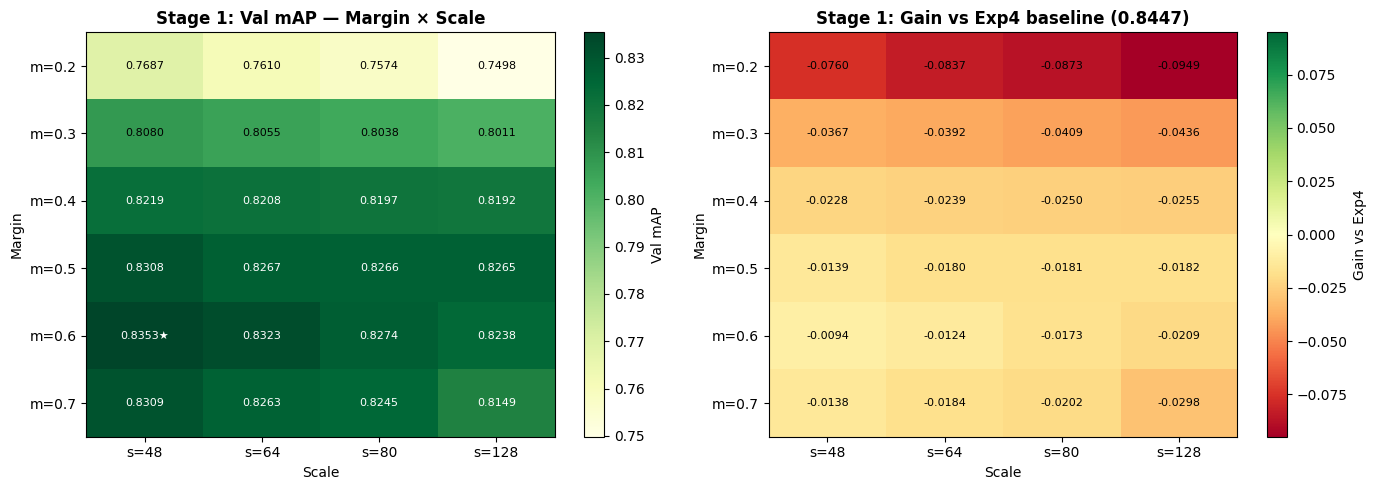

In [10]:
# Heatmap: margin × scale
grid = np.zeros((len(STAGE1_MARGINS), len(STAGE1_SCALES)))
for r in stage1_results:
    i = STAGE1_MARGINS.index(r["margin"])
    j = STAGE1_SCALES.index(r["scale"])
    grid[i, j] = r["val_map"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(grid, cmap='YlGn', aspect='auto')
ax.set_yticks(range(len(STAGE1_MARGINS)))
ax.set_yticklabels([f"m={m}" for m in STAGE1_MARGINS])
ax.set_xticks(range(len(STAGE1_SCALES)))
ax.set_xticklabels([f"s={int(s)}" for s in STAGE1_SCALES])
ax.set_title("Stage 1: Val mAP — Margin × Scale", fontweight='bold')
ax.set_xlabel("Scale"); ax.set_ylabel("Margin")
for i in range(len(STAGE1_MARGINS)):
    for j in range(len(STAGE1_SCALES)):
        best_m = "★" if (STAGE1_MARGINS[i]==best_s1["margin"] and
                          STAGE1_SCALES[j]==best_s1["scale"]) else ""
        ax.text(j, i, f"{grid[i,j]:.4f}{best_m}",
                ha='center', va='center', fontsize=8,
                color='white' if grid[i,j] > grid.mean() else 'black')
plt.colorbar(im, ax=ax, label='Val mAP')

# Gain heatmap (vs Exp4 baseline)
gain_grid = grid - EXP4_BASELINE_MAP
ax = axes[1]
vmax = max(abs(gain_grid.min()), abs(gain_grid.max()))
im2 = ax.imshow(gain_grid, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_yticks(range(len(STAGE1_MARGINS))); ax.set_yticklabels([f"m={m}" for m in STAGE1_MARGINS])
ax.set_xticks(range(len(STAGE1_SCALES)));  ax.set_xticklabels([f"s={int(s)}" for s in STAGE1_SCALES])
ax.set_title(f"Stage 1: Gain vs Exp4 baseline ({EXP4_BASELINE_MAP})", fontweight='bold')
ax.set_xlabel("Scale"); ax.set_ylabel("Margin")
for i in range(len(STAGE1_MARGINS)):
    for j in range(len(STAGE1_SCALES)):
        ax.text(j, i, f"{gain_grid[i,j]:+.4f}",
                ha='center', va='center', fontsize=8)
plt.colorbar(im2, ax=ax, label='Gain vs Exp4')

plt.tight_layout()
wandb.log({"stage1/heatmap": wandb.Image(fig)})
plt.savefig('/kaggle/working/stage1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

wandb.log({"stage1/results_table": wandb.Table(
    dataframe=pd.DataFrame([{k:v for k,v in r.items() if k != 'time_s'}
                             for r in stage1_results]))})


## 5. Stage 2 — Embedding Dimension Sweep

Fixing: best margin+scale from Stage 1, hidden_dim=512, dropout=0.3
Sweeping: embedding_dim ∈ {128, 256, 512, 1024}

DINOv2 outputs 1024-dim features. Compressing to 256 (Exp 4 default) may discard
discriminative information. Larger output dimensions trade off retrieval speed
for representational capacity.


In [11]:
stage2_results = []
best_margin = best_s1["margin"]
best_scale  = best_s1["scale"]

print(f"Stage 2: embedding_dim sweep")
print(f"  Fixed: margin={best_margin}, scale={int(best_scale)} (Stage 1 best)")
print(f"  Fixed: hidden=512, dropout=0.3")
print()

for emb_dim in STAGE2_EMB_DIMS:
    tag = f"dim{emb_dim}"
    t0  = time.perf_counter()
    val_map, best_ep, _, _ = run_config(
        tag=tag, margin=best_margin, scale=best_scale,
        emb_dim=emb_dim, hidden_dim=512, dropout=0.3,
        wandb_prefix=f"stage2/{tag}")
    elapsed = time.perf_counter() - t0
    gain    = val_map - EXP4_BASELINE_MAP

    stage2_results.append({
        "emb_dim": emb_dim, "val_map": val_map,
        "gain": gain, "best_epoch": best_ep,
    })
    marker = " ★ BEST" if val_map == max(r["val_map"] for r in stage2_results) else ""
    print(f"  dim={emb_dim:4d} | mAP={val_map:.4f} ({gain:+.4f}) | "
          f"ep={best_ep:3d} | {elapsed/60:.1f}min{marker}")

stage2_results.sort(key=lambda r: -r["val_map"])
best_s2 = stage2_results[0]
print(f"\nStage 2 best: emb_dim={best_s2['emb_dim']} → mAP={best_s2['val_map']:.4f}")

wandb.log({"stage2/best_emb_dim": best_s2["emb_dim"],
           "stage2/best_map":     best_s2["val_map"],
           "stage2/best_gain":    best_s2["gain"]})


Stage 2: embedding_dim sweep
  Fixed: margin=0.6, scale=48 (Stage 1 best)
  Fixed: hidden=512, dropout=0.3

  dim= 128 | mAP=0.8379 (-0.0068) | ep= 50 | 0.2min ★ BEST
  dim= 256 | mAP=0.8353 (-0.0094) | ep= 50 | 0.2min
  dim= 512 | mAP=0.8555 (+0.0108) | ep= 50 | 0.2min ★ BEST
  dim=1024 | mAP=0.8517 (+0.0070) | ep= 45 | 0.2min

Stage 2 best: emb_dim=512 → mAP=0.8555


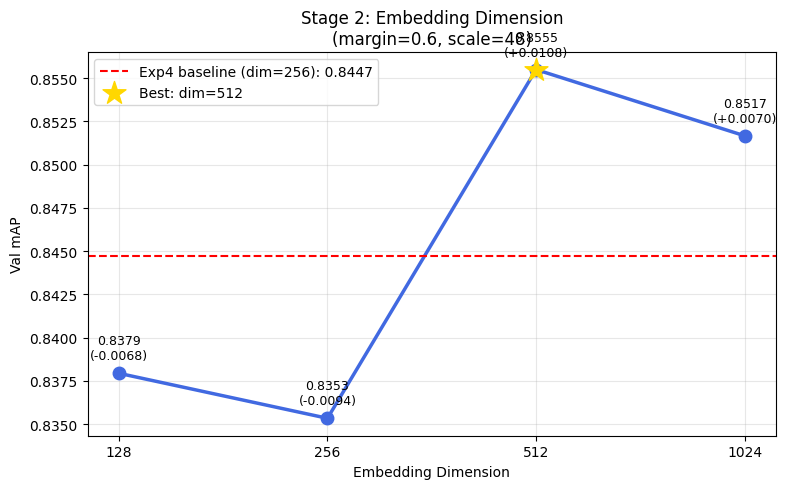

In [12]:
dims  = [r["emb_dim"] for r in sorted(stage2_results, key=lambda x: x["emb_dim"])]
maps  = [r["val_map"] for r in sorted(stage2_results, key=lambda x: x["emb_dim"])]
gains = [r["gain"]    for r in sorted(stage2_results, key=lambda x: x["emb_dim"])]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dims, maps, 'o-', color='royalblue', linewidth=2.5, markersize=9)

for d, m, g in zip(dims, maps, gains):
    ax.annotate(f"{m:.4f}\n({g:+.4f})", (d, m),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9)

ax.axhline(y=EXP4_BASELINE_MAP, color='red', linestyle='--',
           label=f"Exp4 baseline (dim=256): {EXP4_BASELINE_MAP:.4f}")
ax.scatter([best_s2["emb_dim"]], [best_s2["val_map"]], s=300, color='gold',
           zorder=4, marker='*', label=f"Best: dim={best_s2['emb_dim']}")

ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Val mAP")
ax.set_title(f"Stage 2: Embedding Dimension\n(margin={best_margin}, scale={int(best_scale)})")
ax.set_xscale('log', base=2)
ax.set_xticks(dims)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({"stage2/dim_plot": wandb.Image(fig)})
plt.show()


## 6. Stage 3 — Hidden Dim + Dropout Sweep

Fixing: best margin+scale from Stage 1, best emb_dim from Stage 2
Sweeping: hidden_dim ∈ {512, 1024} × dropout ∈ {0.1, 0.3, 0.5}

A wider hidden layer (1024) increases the projection head capacity.
Lower dropout may help when the backbone features are already rich (DINOv2);
higher dropout acts as regularisation for the small identity count.


In [13]:
stage3_results = []
best_emb_dim = best_s2["emb_dim"]

print(f"Stage 3: hidden_dim × dropout sweep")
print(f"  Fixed: margin={best_margin}, scale={int(best_scale)}, emb_dim={best_emb_dim}")
print()

for cfg3 in STAGE3_CONFIGS:
    hidden = cfg3["hidden_dim"]; drop = cfg3["dropout"]
    tag = f"h{hidden}_d{str(drop).replace('.','')}"
    t0  = time.perf_counter()
    val_map, best_ep, best_val_emb, best_proj = run_config(
        tag=tag, margin=best_margin, scale=best_scale,
        emb_dim=best_emb_dim, hidden_dim=hidden, dropout=drop,
        wandb_prefix=f"stage3/{tag}",
        log_curve=(hidden==512 and drop==0.3))   # log full curve for Exp4-equivalent
    elapsed = time.perf_counter() - t0
    gain    = val_map - EXP4_BASELINE_MAP

    stage3_results.append({
        "hidden_dim": hidden, "dropout": drop,
        "val_map": val_map,   "gain": gain,
        "best_epoch": best_ep,
        "val_emb": best_val_emb,   # keep for final analysis
        "proj": best_proj,
    })
    is_exp4_default = (hidden == 512 and drop == 0.3)
    marker = " ★ BEST" if val_map == max(r["val_map"] for r in stage3_results) else ""
    default = " (Exp4 default)" if is_exp4_default else ""
    print(f"  hidden={hidden}, dropout={drop} | "
          f"mAP={val_map:.4f} ({gain:+.4f}) | "
          f"ep={best_ep}{default}{marker}")

stage3_results.sort(key=lambda r: -r["val_map"])
best_s3 = stage3_results[0]
print(f"\nStage 3 best: hidden={best_s3['hidden_dim']}, dropout={best_s3['dropout']} "
      f"→ mAP={best_s3['val_map']:.4f}")

wandb.log({"stage3/best_hidden":  best_s3["hidden_dim"],
           "stage3/best_dropout": best_s3["dropout"],
           "stage3/best_map":     best_s3["val_map"],
           "stage3/best_gain":    best_s3["gain"]})


Stage 3: hidden_dim × dropout sweep
  Fixed: margin=0.6, scale=48, emb_dim=512

  hidden=512, dropout=0.1 | mAP=0.8570 (+0.0123) | ep=46 ★ BEST
  hidden=512, dropout=0.3 | mAP=0.8555 (+0.0108) | ep=50 (Exp4 default)
  hidden=512, dropout=0.5 | mAP=0.8296 (-0.0151) | ep=50
  hidden=1024, dropout=0.1 | mAP=0.8555 (+0.0108) | ep=46
  hidden=1024, dropout=0.3 | mAP=0.8631 (+0.0184) | ep=48 ★ BEST
  hidden=1024, dropout=0.5 | mAP=0.8535 (+0.0088) | ep=49

Stage 3 best: hidden=1024, dropout=0.3 → mAP=0.8631


## 7. Overall Results Summary

In [14]:
# Collect best from each stage + Exp4 baseline
all_summary = [
    {"config": "Exp4 baseline",
     "margin": 0.5, "scale": 64, "emb_dim": 256, "hidden": 512, "dropout": 0.3,
     "val_map": EXP4_BASELINE_MAP, "gain": 0.0},
    {"config": f"Stage1 best (margin={best_s1['margin']}, scale={int(best_s1['scale'])})",
     "margin": best_s1["margin"], "scale": best_s1["scale"],
     "emb_dim": 256, "hidden": 512, "dropout": 0.3,
     "val_map": best_s1["val_map"], "gain": best_s1["gain"]},
    {"config": f"Stage2 best (dim={best_s2['emb_dim']})",
     "margin": best_margin, "scale": best_scale,
     "emb_dim": best_s2["emb_dim"], "hidden": 512, "dropout": 0.3,
     "val_map": best_s2["val_map"], "gain": best_s2["gain"]},
    {"config": f"Stage3 best (hidden={best_s3['hidden_dim']}, drop={best_s3['dropout']})",
     "margin": best_margin, "scale": best_scale,
     "emb_dim": best_emb_dim,
     "hidden": best_s3["hidden_dim"], "dropout": best_s3["dropout"],
     "val_map": best_s3["val_map"], "gain": best_s3["gain"]},
]
best_overall = max(all_summary, key=lambda r: r["val_map"])

print("=" * 70)
print(f"{'Config':45s} | {'mAP':>6} | {'Gain':>7}")
print("-" * 70)
for r in all_summary:
    marker = "  << OVERALL BEST" if r["config"] == best_overall["config"] else ""
    print(f"  {r['config']:43s} | {r['val_map']:.4f} | {r['gain']:+.4f}{marker}")
print("=" * 70)

print(f"\nBest configuration:")
print(f"  margin={best_overall['margin']}, scale={int(best_overall['scale'])}, "
      f"emb_dim={best_overall['emb_dim']}, "
      f"hidden={best_overall['hidden']}, dropout={best_overall['dropout']}")
print(f"  Val mAP: {best_overall['val_map']:.4f}  (Exp4 baseline: {EXP4_BASELINE_MAP:.4f})")
print(f"  Net gain: {best_overall['gain']:+.4f}")

wandb.log({
    "results/best_overall_map":  best_overall["val_map"],
    "results/best_overall_gain": best_overall["gain"],
    "results/best_margin":       best_overall["margin"],
    "results/best_scale":        best_overall["scale"],
    "results/best_emb_dim":      best_overall["emb_dim"],
    "results/best_hidden":       best_overall["hidden"],
    "results/best_dropout":      best_overall["dropout"],
    "results/summary_table":     wandb.Table(dataframe=pd.DataFrame(all_summary)),
})


Config                                        |    mAP |    Gain
----------------------------------------------------------------------
  Exp4 baseline                               | 0.8447 | +0.0000
  Stage1 best (margin=0.6, scale=48)          | 0.8353 | -0.0094
  Stage2 best (dim=512)                       | 0.8555 | +0.0108
  Stage3 best (hidden=1024, drop=0.3)         | 0.8631 | +0.0184  << OVERALL BEST

Best configuration:
  margin=0.6, scale=48, emb_dim=512, hidden=1024, dropout=0.3
  Val mAP: 0.8631  (Exp4 baseline: 0.8447)
  Net gain: +0.0184


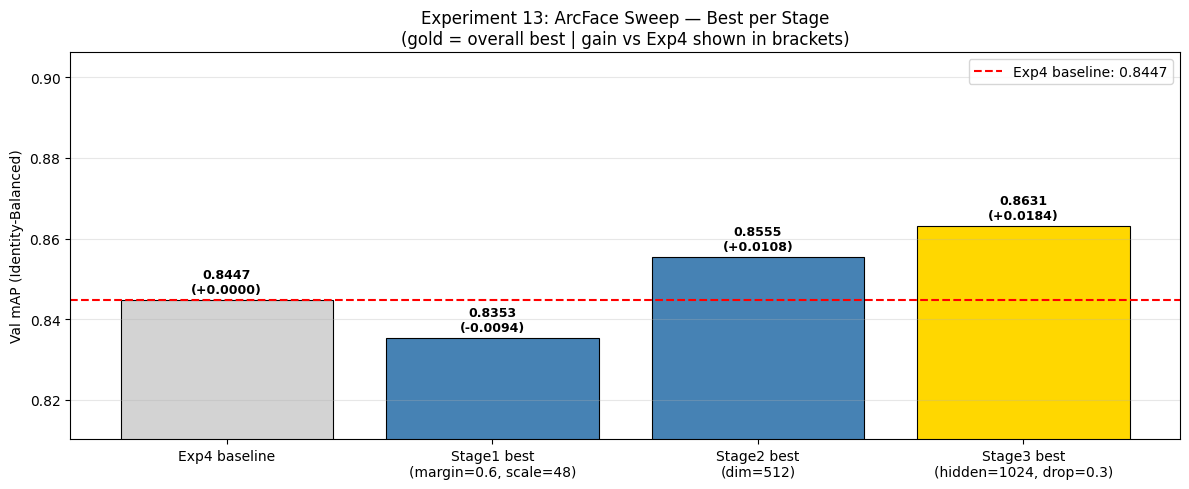

In [15]:
# Final comparison bar chart
configs = [r["config"].replace(" (", "\n(") for r in all_summary]   # \\n → \n
maps    = [r["val_map"] for r in all_summary]
colors  = ['lightgray' if r["config"] == "Exp4 baseline"
           else ('gold' if r["config"] == best_overall["config"]
           else 'steelblue') for r in all_summary]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(configs, maps, color=colors, edgecolor='black', linewidth=0.8)

for bar, val, r in zip(bars, maps, all_summary):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{val:.4f}\n({r['gain']:+.4f})",              # \\n → \n
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=EXP4_BASELINE_MAP, color='red', linestyle='--', linewidth=1.5,
           label=f"Exp4 baseline: {EXP4_BASELINE_MAP:.4f}")
ax.set_ylabel("Val mAP (Identity-Balanced)")
ax.set_title("Experiment 13: ArcFace Sweep — Best per Stage\n"   # raw newline → \n
             "(gold = overall best | gain vs Exp4 shown in brackets)")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(min(maps) * 0.97, max(maps) * 1.05)
plt.tight_layout()
wandb.log({"results/summary_bar": wandb.Image(fig)})
plt.savefig('/kaggle/working/exp13_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Generate Submission with Best Configuration

In [16]:
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")
test_images   = sorted(set(test_pairs_df['query_image'].unique()) |
                        set(test_pairs_df['gallery_image'].unique()))
test_paths    = [config["data_dir"] / "test/test" / fn for fn in test_images]
print(f"Test images: {len(test_images)}  |  Test pairs: {len(test_pairs_df)}")

# Load or extract test backbone embeddings
te_cache = config["cache_dir"] / "dinov2_test_embeddings.npz"
if te_cache.exists():
    test_bb = np.load(te_cache)["embeddings"]
    print(f"Loaded test backbone cache: {test_bb.shape}")
else:
    print("Extracting DINOv2 test embeddings...")
    backbone = timm.create_model(config["dinov2_model"], pretrained=True,
                                  num_classes=0, img_size=518)
    backbone.eval()
    for p in backbone.parameters(): p.requires_grad = False
    backbone.to(device)
    preprocess = transforms.Compose([
        transforms.Resize((518,518)), transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    out = []
    for i in tqdm(range(0, len(test_paths), 32), desc="DINOv2 test"):
        tensors = []
        for p in test_paths[i:i+32]:
            try:    tensors.append(preprocess(Image.open(p).convert("RGB")))
            except: tensors.append(torch.zeros(3,518,518))
        out.append(backbone(torch.stack(tensors).to(device)).cpu().numpy())
    test_bb = np.vstack(out)
    np.savez_compressed(te_cache, embeddings=test_bb)
    del backbone; torch.cuda.empty_cache()
    print(f"Extracted: {test_bb.shape}")

# Re-train best overall config on full data to get test projection
print(f"\nApplying best config: {best_overall['config']}")
_, _, _, best_proj_final = run_config(
    tag="final",
    margin=best_overall["margin"],
    scale=float(best_overall["scale"]),
    emb_dim=best_overall["emb_dim"],
    hidden_dim=best_overall["hidden"],
    dropout=best_overall["dropout"],
    wandb_prefix="final_retrain",
)

with torch.no_grad():
    test_emb = best_proj_final.get_embeddings(
        torch.FloatTensor(test_bb).to(device)).cpu().numpy()
test_emb = test_emb / (np.linalg.norm(test_emb, axis=1, keepdims=True) + 1e-12)

img_to_idx = {img: i for i, img in enumerate(test_images)}
sims = np.clip([
    float(np.dot(test_emb[img_to_idx[r['query_image']]],
                 test_emb[img_to_idx[r['gallery_image']]]))
    for _, r in tqdm(test_pairs_df.iterrows(),
                      total=len(test_pairs_df), desc="Submission")
], 0.0, 1.0)

pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': sims})  .to_csv('/kaggle/working/submission.csv', index=False)
print(f"Submission saved.  sim: min={sims.min():.4f} max={sims.max():.4f} mean={sims.mean():.4f}")


Test images: 371  |  Test pairs: 137270
Extracting DINOv2 test embeddings...


DINOv2 test:   0%|          | 0/12 [00:00<?, ?it/s]

Extracted: (371, 1024)

Applying best config: Stage3 best (hidden=1024, drop=0.3)


Submission:   0%|          | 0/137270 [00:00<?, ?it/s]

Submission saved.  sim: min=0.0000 max=0.9969 mean=0.0633


In [17]:
sub_art = wandb.Artifact("submission", type="submission",
    description=f"ArcFace sweep best: {best_overall['config']}")
sub_art.add_file("/kaggle/working/submission.csv")
wandb.log_artifact(sub_art)
wandb.finish()
print("W&B run completed.")
print(f"\nFinal result:  {best_overall['val_map']:.4f}  "
      f"({'improved' if best_overall['gain'] > 0 else 'no improvement'} "
      f"vs Exp4 baseline of {EXP4_BASELINE_MAP:.4f}, gain={best_overall['gain']:+.4f})")


final_retrain/best_epoch,▁
final_retrain/best_map,▁
final_retrain/gain,▁
results/best_dropout,▁
results/best_emb_dim,▁
results/best_hidden,▁
results/best_margin,▁
results/best_overall_gain,▁
results/best_overall_map,▁
results/best_scale,▁
+117,...


W&B run completed.

Final result:  0.8631  (improved vs Exp4 baseline of 0.8447, gain=+0.0184)
